In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/pollution/24pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,0.580495
2014-07-04 12:00:00,0.570041,0.600903
2014-07-04 13:00:00,0.405458,0.494388
2014-07-04 14:00:00,0.405458,0.417649
2014-07-04 15:00:00,0.427403,0.287554


In [3]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/pollution/24pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,0.166310
2014-07-04 12:00:00,0.570041,0.157855
2014-07-04 13:00:00,0.405458,0.118628
2014-07-04 14:00:00,0.405458,0.074869
2014-07-04 15:00:00,0.427403,0.038151


In [4]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/pollution/24pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,0.220450
2014-07-04 12:00:00,0.570041,0.205659
2014-07-04 13:00:00,0.405458,0.143265
2014-07-04 14:00:00,0.405458,0.107181
2014-07-04 15:00:00,0.427403,0.075589


In [5]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/pollution/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.200241
2014-07-04 22:00:00,0.559069,0.291358
2014-07-04 23:00:00,0.613930,0.293672
2014-07-05 00:00:00,0.745596,0.329007
2014-07-05 01:00:00,0.789484,0.261832


In [6]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/pollution/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.434569
2014-07-04 22:00:00,0.559069,0.794278
2014-07-04 23:00:00,0.613930,0.798075
2014-07-05 00:00:00,0.745596,0.968433
2014-07-05 01:00:00,0.789484,0.966470


In [7]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/pollution/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-06-30 07:00:00,-0.219955,-0.308641
2014-06-30 08:00:00,-0.384538,-0.110149
2014-06-30 09:00:00,-0.428427,-0.171933
2014-06-30 10:00:00,-0.395510,-0.214443
2014-06-30 11:00:00,-0.318705,-0.145446


# 48 pasos al pasado

In [8]:
datosMLP48 = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/4824paso/4824pasos_mlp_pollution.csv')

datosMLP48['date'] = pd.to_datetime(datosMLP48['Unnamed: 0'])
datosMLP48 = datosMLP48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP48.set_index('date', inplace=True)

datosMLP48.head()


,Originales,Predichos
date,,
2014-07-04 14:00:00,0.405458,0.438989
2014-07-04 15:00:00,0.427403,0.238871
2014-07-04 16:00:00,0.855317,0.217593
2014-07-04 17:00:00,1.096705,0.185321
2014-07-04 18:00:00,1.239343,0.195829


In [9]:
datosLSTM48 = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/4824paso/4824pasos_lstm_pollution.csv')

datosLSTM48['date'] = pd.to_datetime(datosLSTM48['Unnamed: 0'])
datosLSTM48 = datosLSTM48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM48.set_index('date', inplace=True)

datosLSTM48.head()

,Originales,Predichos
date,,
2014-07-04 14:00:00,0.405458,0.005377
2014-07-04 15:00:00,0.427403,-0.034079
2014-07-04 16:00:00,0.855317,-0.066153
2014-07-04 17:00:00,1.096705,-0.082829
2014-07-04 18:00:00,1.239343,-0.082646


In [10]:
datosGRU48= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/4824paso/4824pasos_gru_pollution.csv')

datosGRU48['date'] = pd.to_datetime(datosGRU48['Unnamed: 0'])
datosGRU48 = datosGRU48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU48.set_index('date', inplace=True)

datosGRU48.head()

,Originales,Predichos
date,,
2014-07-04 14:00:00,0.405458,0.415364
2014-07-04 15:00:00,0.427403,0.323846
2014-07-04 16:00:00,0.855317,0.279921
2014-07-04 17:00:00,1.096705,0.258455
2014-07-04 18:00:00,1.239343,0.245754


In [11]:
datosCross48 = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/4824paso/crossformerPollution.csv')

datosCross48['date'] = pd.to_datetime(datosCross48['Unnamed: 0'])
datosCross48 = datosCross48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross48.set_index('date', inplace=True)

datosCross48.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.073292
2014-07-06 10:00:00,1.283232,-0.106070
2014-07-06 11:00:00,1.052817,-0.075329
2014-07-06 12:00:00,0.877262,-0.146368
2014-07-06 13:00:00,0.624902,-0.231192


In [12]:
datosI48= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/4824paso/itransformerPollution.csv')

datosI48['date'] = pd.to_datetime(datosI48['Unnamed: 0'])
datosI48 = datosI48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI48.set_index('date', inplace=True)

datosI48.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,0.826216
2014-07-06 10:00:00,1.283232,0.491225
2014-07-06 11:00:00,1.052817,0.850267
2014-07-06 12:00:00,0.877262,0.750340
2014-07-06 13:00:00,0.624902,0.040241


In [13]:
datosTFT48= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/4824paso/tftPollution.csv')

datosTFT48['date'] = pd.to_datetime(datosTFT48['Unnamed: 0'])
datosTFT48 = datosTFT48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT48.set_index('date', inplace=True)

datosTFT48.head()

,Originales,Predichos
date,,
2014-07-01 19:00:00,0.690735,-0.209891
2014-07-01 20:00:00,0.745596,-0.230509
2014-07-01 21:00:00,0.537124,-0.225396
2014-07-01 22:00:00,-0.373566,-0.198562
2014-07-01 23:00:00,-0.571065,-0.197193


In [14]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])


rMLP48 = pd.DataFrame(datosMLP48['Originales'] - datosMLP48['Predichos'], columns=['MLP48'])
rLSTM48 = pd.DataFrame(datosLSTM48['Originales'] - datosLSTM48['Predichos'], columns=['LSTM48'])
rGRU48 = pd.DataFrame(datosGRU48['Originales'] - datosGRU48['Predichos'], columns=['GRU48'])
rCross48 = pd.DataFrame(datosCross48['Originales'] - datosCross48['Predichos'], columns=['Crossformer48'])
rI48 = pd.DataFrame(datosI48['Originales'] - datosI48['Predichos'], columns=['iTransformer48'])
rTFT48 = pd.DataFrame(datosTFT48['Originales'] - datosTFT48['Predichos'], columns=['TFT48'])


In [15]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer').join(rMLP48, how='outer').join(rLSTM48, how='outer').join(rGRU48, how='outer').join(rCross48, how='outer').join(rI48, how='outer').join(rTFT48, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLP48,LSTM48,GRU48,Crossformer48,iTransformer48,TFT48
date,,,,,,,,,,,,
2014-06-30 07:00:00,NaN,NaN,NaN,NaN,NaN,0.088685,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30 08:00:00,NaN,NaN,NaN,NaN,NaN,-0.274389,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30 09:00:00,NaN,NaN,NaN,NaN,NaN,-0.256494,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30 10:00:00,NaN,NaN,NaN,NaN,NaN,-0.181067,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30 11:00:00,NaN,NaN,NaN,NaN,NaN,-0.173259,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLP48,LSTM48,GRU48,Crossformer48,iTransformer48,TFT48
date,,,,,,,,,,,,
2014-07-06 09:00:00,1.182878,1.194787,1.132724,1.364932,1.160941,1.174391,1.087315,1.323107,1.094855,1.367496,0.467988,1.160783
2014-07-06 10:00:00,1.195512,1.207259,1.150792,1.379778,1.181883,1.185237,1.165488,1.344055,1.143309,1.389303,0.792007,1.170748
2014-07-06 11:00:00,0.954293,0.990400,0.893839,1.097871,0.943225,0.933992,0.922651,1.136443,0.915660,1.128146,0.202550,0.921345
2014-07-06 12:00:00,0.866339,0.837644,0.752539,0.968794,0.823967,0.805469,0.913304,0.968421,0.787144,1.023630,0.126922,0.782146
2014-07-06 13:00:00,0.699099,0.627028,0.557749,0.784292,0.611301,0.606507,0.854942,0.740322,0.605488,0.856094,0.584661,0.589431


In [17]:
import scipy.stats as stats



In [18]:
final = final.sample(frac=0.10, random_state=42)

In [19]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [20]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


9.207842529979722e-12


In [21]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


2.547615794149054e-08


In [22]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


2.54547574945239e-10


In [23]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


5.914559183209188e-08


In [24]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


7.845238371339308e-07


In [25]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


5.3619018632515154e-08


In [26]:
W, p = kstest(final["MLP48"], norm.cdf, args=(0, 1))
print(p)


4.329503177005182e-10


In [27]:
W, p = kstest(final["LSTM48"], norm.cdf, args=(0, 1))
print(p)


1.0485690863351085e-07


In [28]:
W, p = kstest(final["GRU48"], norm.cdf, args=(0, 1))
print(p)


2.8655665795112138e-08


In [29]:
W, p = kstest(final["Crossformer48"], norm.cdf, args=(0, 1))
print(p)


1.4536371625134375e-07


In [30]:
W, p = kstest(final["iTransformer48"], norm.cdf, args=(0, 1))
print(p)


1.7345510872229118e-07


In [31]:
W, p = kstest(final["TFT48"], norm.cdf, args=(0, 1))
print(p)


1.0503998438773556e-08


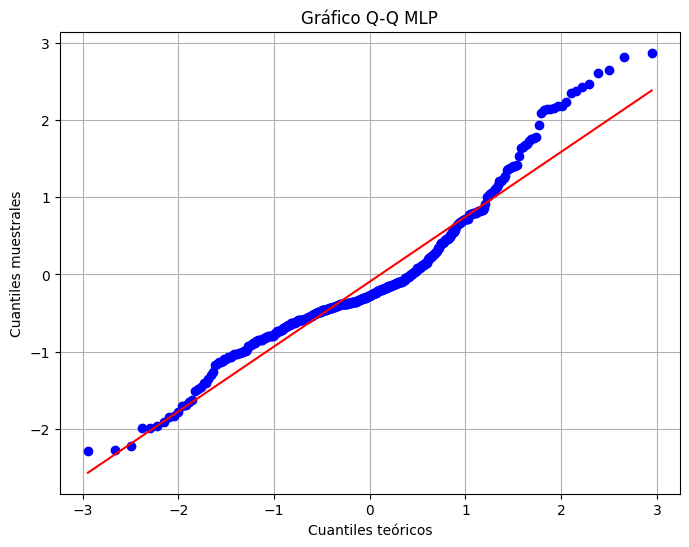

In [32]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

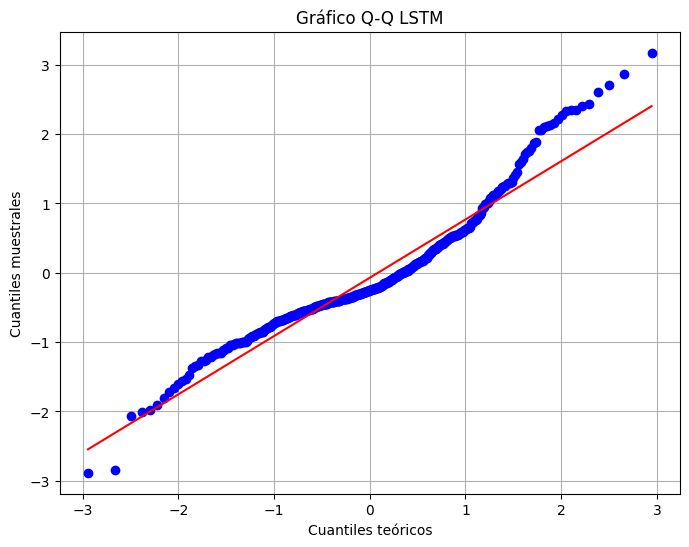

In [33]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

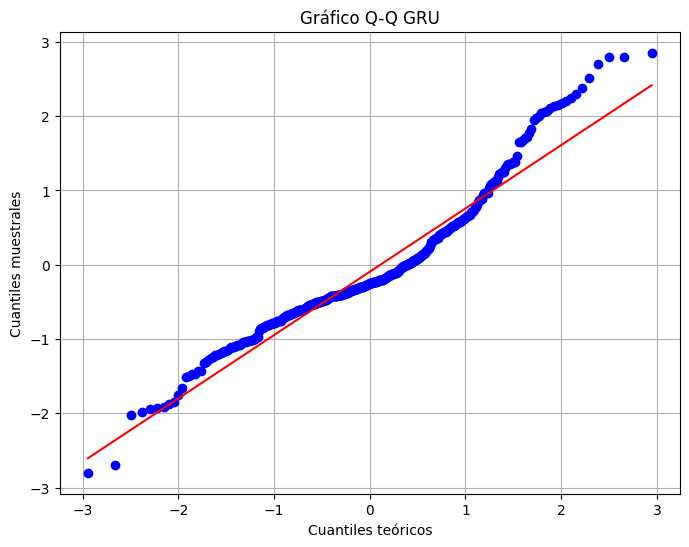

In [34]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

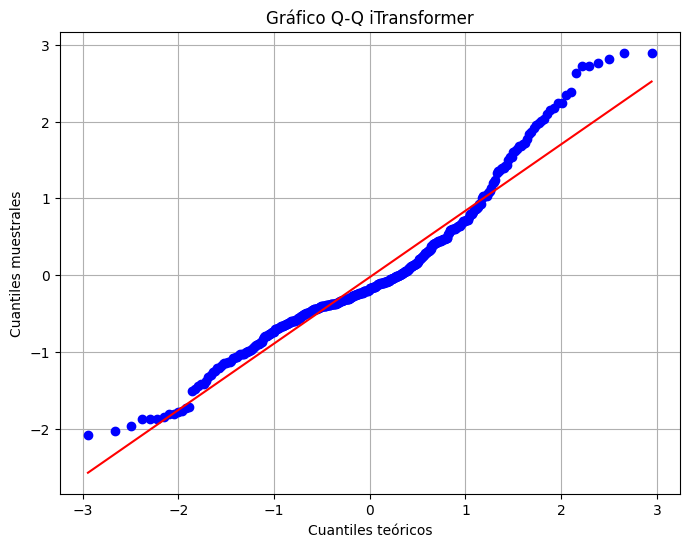

In [35]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

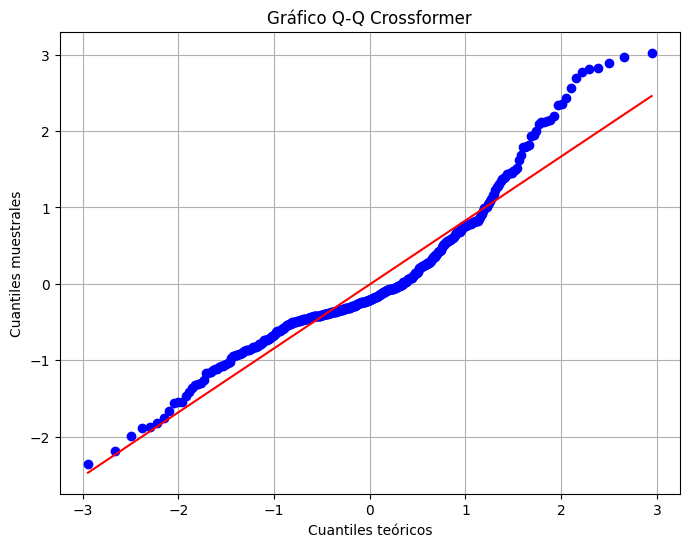

In [36]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

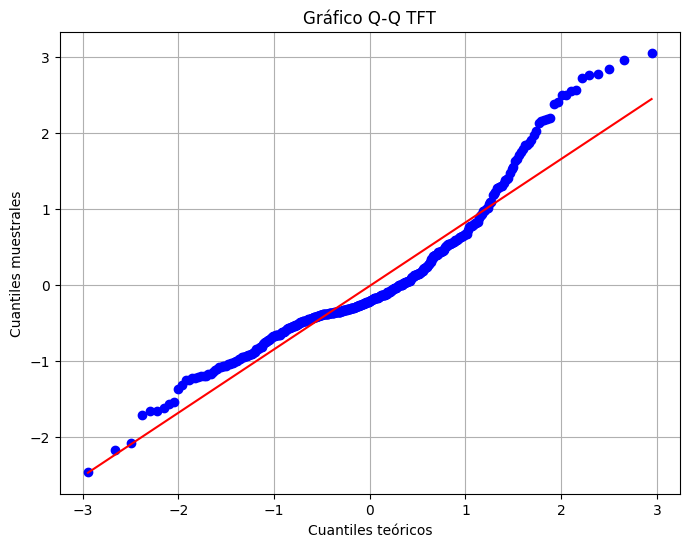

In [37]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

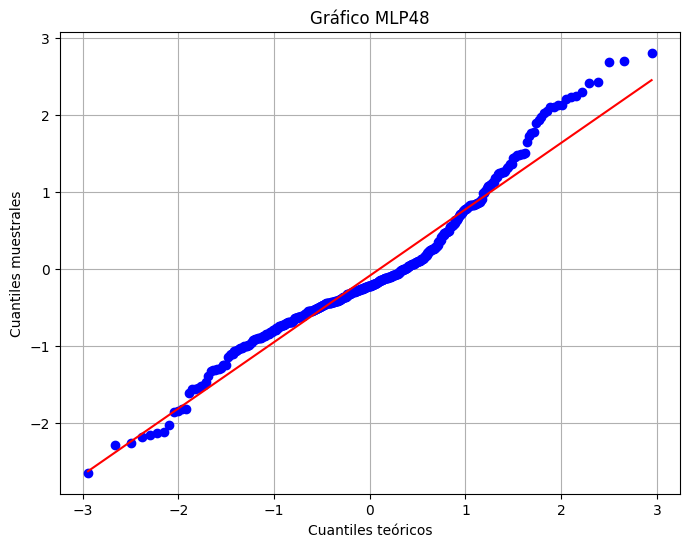

In [38]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP48"], dist="norm", plot=plt)
plt.title('Gráfico MLP48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

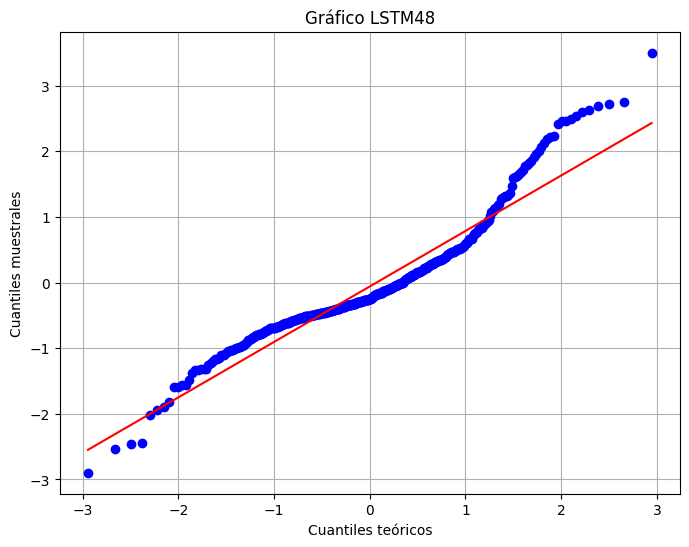

In [39]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM48"], dist="norm", plot=plt)
plt.title('Gráfico LSTM48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

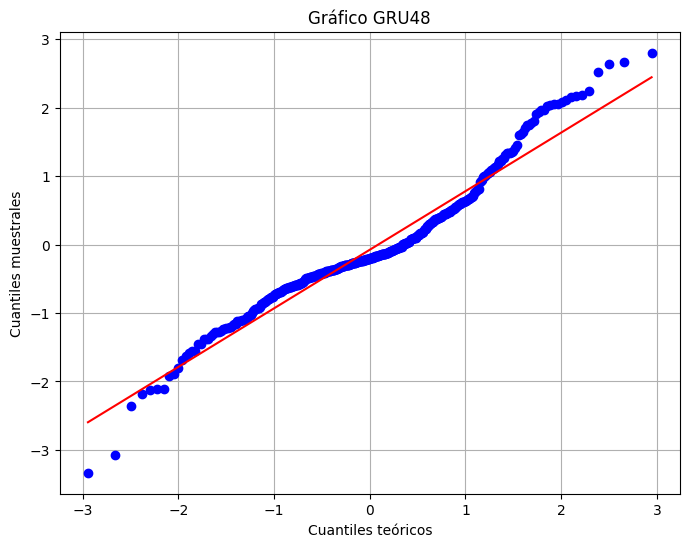

In [40]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU48"], dist="norm", plot=plt)
plt.title('Gráfico GRU48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

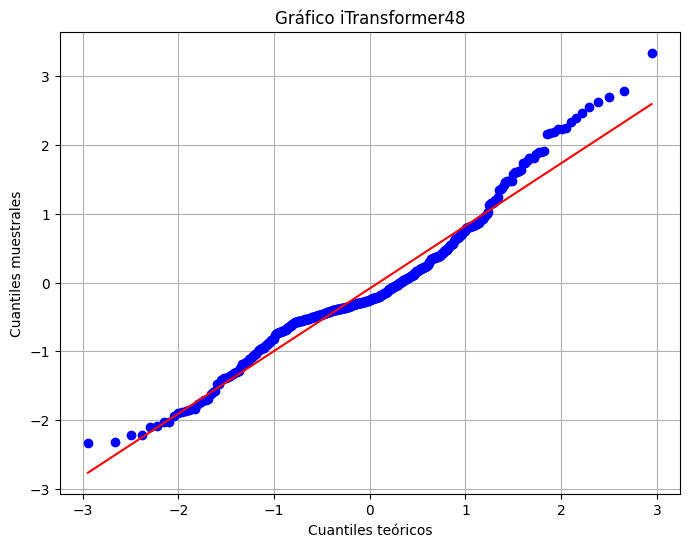

In [41]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer48"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

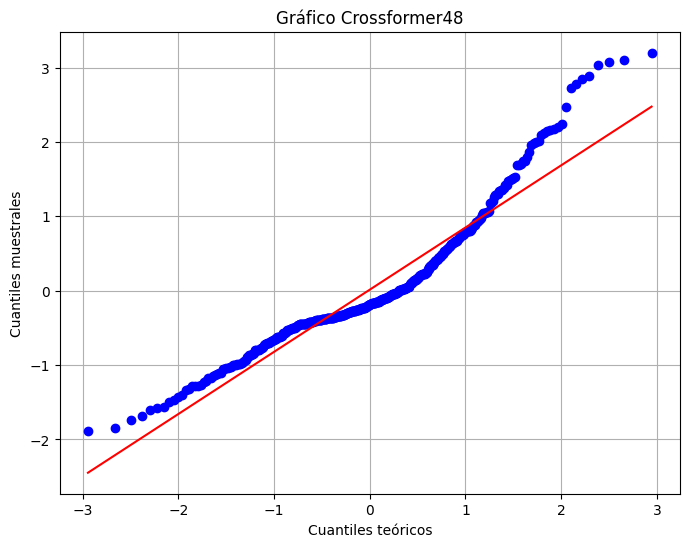

In [42]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer48"], dist="norm", plot=plt)
plt.title('Gráfico Crossformer48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

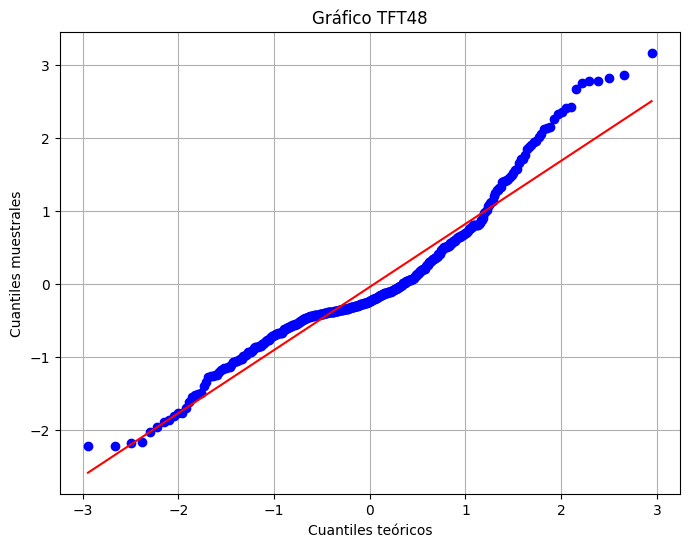

In [43]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT48"], dist="norm", plot=plt)
plt.title('Gráfico TFT48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [44]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

3.139441183175803e-54


In [49]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'MLP48'),
    ('LSTM', 'LSTM48'),
    ('GRU', 'GRU48'),
    ('Crossformer', 'Crossformer48'),
    ('iTransformer', 'iTransformer48'),
    ('TFT', 'TFT48'),
    ('MLP48', 'LSTM48'),
    ('MLP48', 'GRU48'),
    ('MLP48', 'Crossformer48'),
    ('MLP48', 'iTransformer48'),
    ('MLP48', 'TFT48'),
    ('LSTM48', 'GRU48'),
    ('LSTM48', 'Crossformer48'),
    ('LSTM48', 'iTransformer48'),
    ('LSTM48', 'TFT48'),
    ('GRU48', 'Crossformer48'),
    ('GRU48', 'iTransformer48'),
    ('GRU48', 'TFT48'),
    ('Crossformer48', 'iTransformer48'),
    ('Crossformer48', 'TFT48'),
    ('iTransformer48', 'TFT48'),
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs MLP48,0.18519,1.00000,1.00000
1,LSTM vs LSTM48,0.16776,1.00000,1.00000
2,GRU vs GRU48,0.00004,0.00092,0.00066
3,Crossformer vs Crossformer48,0.06747,1.00000,0.67559
4,iTransformer vs iTransformer48,0.00002,0.00035,0.00027
5,TFT vs TFT48,0.04379,0.91952,0.56923
6,MLP48 vs LSTM48,0.33378,1.00000,1.00000
7,MLP48 vs GRU48,0.28077,1.00000,1.00000
8,MLP48 vs Crossformer48,0.00000,0.00000,0.00000
9,MLP48 vs iTransformer48,0.36380,1.00000,1.00000
